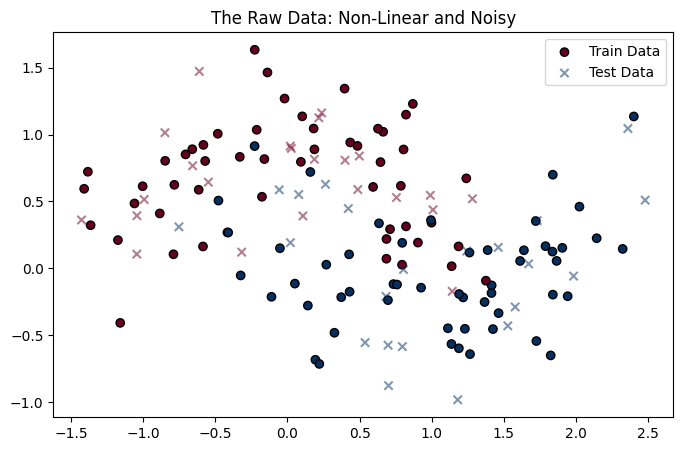

In [ ]:
# First, let's import the necessary libraries.
# NumPy is crucial for numerical operations, especially with arrays.
import numpy as np
# Matplotlib is our go-to library for creating visualizations like plots.
import matplotlib.pyplot as plt
# From scikit-learn, `make_moons` helps us generate a synthetic, non-linear dataset.
from sklearn.datasets import make_moons
# `train_test_split` is used to divide our data into training and testing sets,
# which is essential for evaluating model performance on unseen data.
from sklearn.model_selection import train_test_split

# --- Data Generation ---
# We're generating a dataset that resembles two intertwined half-moons.
# This is a classic synthetic dataset for testing classification algorithms
# on non-linearly separable data.
# `n_samples=150`: We'll create 150 data points in total.
# `noise=0.30`: We add a bit of random noise to make the problem more realistic and challenging.
# `random_state=42`: This ensures that our data generation is reproducible.
#                    If you run this code again, you'll get the exact same dataset.
X, y = make_moons(n_samples=150, noise=0.30, random_state=42)

# --- Data Splitting ---
# Now, we split our generated data into training and testing sets.
# The model will learn from the training data and be evaluated on the test data.
# `test_size=0.3`: 30% of the data will be used for testing, and 70% for training.
# `random_state=42`: Again, for reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- Data Visualization ---
# It's always a good practice to visualize your raw data to understand its distribution
# and whether the classes are easily separable.
plt.figure(figsize=(8, 5)) # Creates a new figure and sets its size to 8x5 inches.

# Plotting the training data:
# `X_train[:, 0]` refers to the first feature (x-coordinate) of the training data.
# `X_train[:, 1]` refers to the second feature (y-coordinate) of the training data.
# `c=y_train`: The color of each point is determined by its class label (y_train).
# `cmap='RdBu'`: Uses a Red-Blue colormap to distinguish between classes.
# `edgecolors='k'`: Adds a black edge to each point for better visibility.
# `label='Train Data'`: A label for this set of points, to be used in the legend.
plt.scatter(
    X_train[:, 0], X_train[:, 1],
    c=y_train, cmap='RdBu', edgecolors='k', label='Train Data'
)

# Plotting the test data:
# Similar to training data, but we use a different marker and transparency
# to visually distinguish it from the training data.
# `marker='x'`: Uses 'x' symbols for test points.
# `alpha=0.5`: Makes the test points semi-transparent.
plt.scatter(
    X_test[:, 0], X_test[:, 1],
    c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data'
)

plt.title("The Raw Data: Non-Linear and Noisy") # Sets the title of our plot.
plt.legend() # Displays the legend, showing what 'Train Data' and 'Test Data' represent.
plt.show() # Renders the plot and displays it.

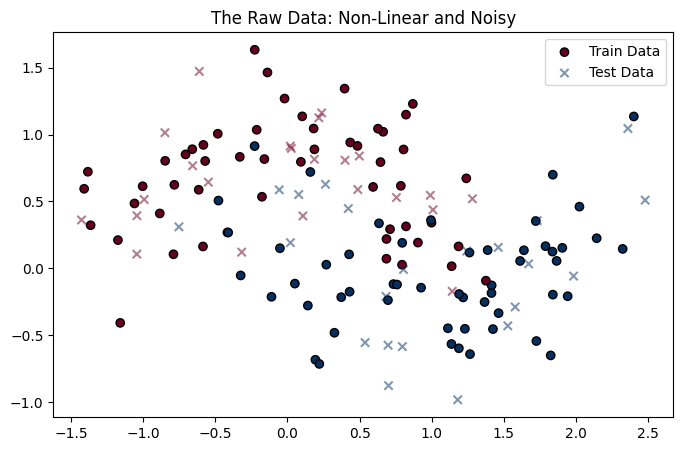

In [ ]:
# Let's bring in all the libraries we'll need for this exercise.
# We'll import them at the top of the notebook for clarity.

# NumPy: The fundamental package for numerical computation in Python.
import numpy as np
# Matplotlib: A comprehensive library for creating static, animated, and interactive visualizations in Python.
import matplotlib.pyplot as plt
# make_moons: A scikit-learn utility to generate a synthetic dataset, ideal for demonstrating non-linear classification.
from sklearn.datasets import make_moons
# train_test_split: A crucial tool from scikit-learn for dividing datasets into training and testing subsets.
from sklearn.model_selection import train_test_split
# PolynomialFeatures: Used to transform our original features into a higher-dimensional space
# by adding polynomial combinations of the original features.
from sklearn.preprocessing import PolynomialFeatures
# LinearRegression, Lasso, Ridge: These are our linear models. LinearRegression is standard,
# Lasso (L1) and Ridge (L2) are regularized versions that help prevent overfitting.
from sklearn.linear_model import LinearRegression, Lasso, Ridge
# mean_squared_error, r2_score: Metrics to evaluate the performance of our regression models.
# MSE measures the average squared difference between predictions and actual values.
# R2 score (coefficient of determination) indicates the proportion of variance in the dependent variable
# that can be predicted from the independent variable(s).
from sklearn.metrics import mean_squared_error, r2_score

# --- Data Generation ---
# We'll create our 'moons' dataset, which is inherently non-linear and noisy.
# This makes it a great candidate for demonstrating how polynomial features and regularization can help.
# `n_samples=150`: We'll generate 150 data points.
# `noise=0.30`: A standard deviation of 0.30 for Gaussian noise added to the data.
# `random_state=42`: Ensures our dataset is the same every time we run the code for reproducibility.
X, y = make_moons(n_samples=150, noise=0.30, random_state=42)

# --- Data Splitting ---
# To properly evaluate our models, we split the data into a training set and a testing set.
# The training set is used to 'teach' the model, and the test set is used to assess its performance
# on data it has never seen before.
# `test_size=0.3`: This means 30% of the data will be held back for testing.
# `random_state=42`: Ensures the split is consistent across runs.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- Data Visualization ---
# Visualizing the data helps us understand its structure and the challenge it presents to linear models.
plt.figure(figsize=(8, 5)) # Create a plot figure with a specific size.

# Plot the training data points.
# `X_train[:, 0]` are the x-coordinates, `X_train[:, 1]` are the y-coordinates.
# `c=y_train`: Color points based on their class label (0 or 1).
# `cmap='RdBu'`: Use a red-blue color map for distinct classes.
# `edgecolors='k'`: Add black outlines to points for better definition.
# `label='Train Data'`: Provide a label for the legend.
plt.scatter(
    X_train[:, 0], X_train[:, 1],
    c=y_train, cmap='RdBu', edgecolors='k', label='Train Data'
)

# Plot the testing data points.
# Use a different marker ('x') and transparency (`alpha=0.5`) to distinguish test points.
plt.scatter(
    X_test[:, 0], X_test[:, 1],
    c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data'
)

plt.title("The Raw Data: Non-Linear and Noisy") # Set the title for the plot.
plt.legend() # Display the legend to identify train and test data.
plt.show() # Show the generated plot.

<!-- This cell explains the purpose of generating polynomial features. -->

### Why Polynomial Features?

Our 'moons' dataset is clearly non-linear. A simple linear model (a straight line) would struggle to separate these two classes effectively. To allow linear models to capture these complex, curved relationships, we can transform our existing features into a higher-dimensional space.

**First, we'll create polynomial features up to degree 10 for both the training and testing datasets.** This means that for each original feature (say, `x1` and `x2`), we'll create new features like `x1^2`, `x2^2`, `x1*x2`, `x1^3`, and so on, up to the 10th power and all cross-product combinations. This transformation effectively allows a linear model to fit a polynomial (curved) boundary in the original feature space, because it becomes a linear model in the *transformed* higher-dimensional space.

In [ ]:
# --- Generating Polynomial Features ---

degree = 10 # We define the 'degree' for our polynomial features.
# A higher degree allows for more complex curves but also increases the risk of overfitting.
# Here, we've chosen 10, as specified in the problem.

# Initialize PolynomialFeatures:
# `degree=degree`: Specifies the maximum degree of the polynomial features.
# `include_bias=False`: We typically set this to False when working with scikit-learn's linear models,
#                      as they often add their own intercept (bias) term internally.
poly_features = PolynomialFeatures(degree=degree, include_bias=False) # Initialize PolynomialFeatures transformer

# Fit the transformer and transform the training data:
# `fit_transform()`: This method first 'learns' the polynomial combinations from the training data (`X_train`)
#                   and then applies this transformation to `X_train` itself.
# It's crucial to fit ONLY on the training data to prevent 'data leakage' from the test set.
X_train_poly = poly_features.fit_transform(X_train)

# Transform the test data:
# `transform()`: We only apply the *already learned* transformation to the test data (`X_test`).
#                We do NOT fit on the test data, as that would introduce bias.
X_test_poly = poly_features.transform(X_test)

# --- Verifying Transformation ---
# Let's print the shapes of our datasets to see how the dimensionality has changed.
# Our original X_train had 2 features.
print(f"Original X_train shape: {X_train.shape}")
# After transformation, X_train_poly now has significantly more features (e.g., for degree 10 with 2 original features, it will have 65 features).
print(f"Transformed X_train_poly shape: {X_train_poly.shape}")

Original X_train shape: (105, 2)
Transformed X_train_poly shape: (105, 65)


<!-- This cell explains the purpose of training a standard Linear Regression model on polynomial features. -->

### Training a Standard Polynomial Regression Model

Now that we have transformed our data into a higher-dimensional polynomial space, we can apply a standard linear regression model. Even though it's called 'linear regression,' because we've engineered polynomial features, the model will effectively fit a non-linear curve in our original 2D space.

**Without any regularization (L1 or L2), this model is prone to overfitting,** especially with a high degree like 10, as it will try to fit every data point, including the noise. We'll observe this effect in its performance metrics and decision boundary.

We'll evaluate its performance using two common regression metrics:
*   **Mean Squared Error (MSE):** This measures the average of the squares of the errors (the difference between the actual and predicted values). Lower MSE indicates better fit.
*   **R-squared ($R^2$) score:** This represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R-squared (closer to 1) indicates a better fit. A negative R-squared means the model is worse than simply predicting the mean of the target variable.

In [ ]:
# --- 1. Polynomial Regression without L1 and L2 regularization (Standard Linear Regression) ---

# Initialize the Linear Regression model:
# This is a basic linear model that finds the best-fitting hyperplane through the data.
lin_reg = LinearRegression()

# Train the model:
# We fit the model using our high-dimensional polynomial training features (X_train_poly)
# and the corresponding training labels (y_train).
lin_reg.fit(X_train_poly, y_train)

# --- Making Predictions ---
# Generate predictions for both the training and test sets.
# This allows us to assess how well the model learned (training predictions)
# and how well it generalizes to new, unseen data (test predictions).
y_train_pred_lin = lin_reg.predict(X_train_poly)
y_test_pred_lin = lin_reg.predict(X_test_poly)

# --- Evaluating the Model ---
# Calculate Mean Squared Error (MSE):
# MSE quantifies the average squared difference between the actual and predicted values.
# A lower MSE indicates a better fit.
mse_train_lin = mean_squared_error(y_train, y_train_pred_lin)
mse_test_lin = mean_squared_error(y_test, y_test_pred_lin)

# Calculate R-squared (R2) score:
# R2 score measures the proportion of variance in the dependent variable that is predictable.
# Values closer to 1 are better. A very low or negative R2 on the test set is a strong indicator of overfitting.
r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_test_pred_lin)

# --- Printing Results ---
print("--- Standard Polynomial Regression ---")
print(f"Train MSE: {mse_train_lin:.4f}, Test MSE: {mse_test_lin:.4f}")
print(f"Train R2: {r2_train_lin:.4f}, Test R2: {r2_test_lin:.4f}")

# **Observation:** Notice the significant difference between training and testing metrics.
# A very low training MSE and high R2 (good fit on training data) combined with
# an extremely high test MSE and negative R2 (terrible fit on test data) is a classic sign of **severe overfitting**.
# The model has learned the training data, including its noise, too well and cannot generalize.

--- Standard Polynomial Regression ---
Train MSE: 0.0500, Test MSE: 4130.1940
Train R2: 0.7999, Test R2: -16527.9383


<!-- This cell explains the purpose of training a Lasso Regression model. -->

### Training a Lasso Regression Model (L1 Regularization)

Given the severe overfitting observed with the standard polynomial regression, we now introduce regularization techniques to improve the model's ability to generalize to new data. The first one is Lasso Regression.

**Lasso Regression incorporates L1 regularization.** This type of regularization adds a penalty equal to the absolute value of the magnitude of coefficients to the loss function. Its effect is two-fold:
1.  **Shrinks coefficients:** It drives some coefficients towards zero, reducing their influence.
2.  **Feature selection:** Critically, it can shrink some coefficients *exactly* to zero, effectively removing the corresponding features from the model. This means Lasso can perform automatic feature selection, leading to sparser models (models with fewer features).

We'll use an arbitrary `alpha` value for now, which controls the strength of the regularization. A higher `alpha` means stronger regularization.

In [ ]:
# --- 2. Polynomial Regression with L1 regularization (Lasso) ---

# Initialize the Lasso Regression model:
# `alpha=0.01`: This is the regularization strength. A value of 0 means no regularization (like Linear Regression),
#               and higher values increase the penalty. We start with 0.01 as a common initial choice.
# `max_iter=10000`: The maximum number of iterations for the optimization algorithm. Lasso can sometimes require more iterations to converge.
# `random_state=42`: For reproducibility of the optimization process.
lasso_reg = Lasso(alpha=0.01, max_iter=10000, random_state=42)

# Train the model:
# We fit the Lasso model on our polynomial training data.
lasso_reg.fit(X_train_poly, y_train)

# --- Making Predictions ---
y_train_pred_lasso = lasso_reg.predict(X_train_poly)
y_test_pred_lasso = lasso_reg.predict(X_test_poly)

# --- Evaluating the Model ---
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

# --- Printing Results ---
print("--- Lasso Polynomial Regression ---")
print(f"Train MSE: {mse_train_lasso:.4f}, Test MSE: {mse_test_lasso:.4f}")
print(f"Train R2: {r2_train_lasso:.4f}, Test R2: {r2_test_lasso:.4f}")

# **Observation:** Notice the significant improvement in test MSE and R2 compared to the standard Linear Regression.
# The test MSE is drastically lower, and the R2 is now positive, indicating that Lasso effectively reduced overfitting.
# The `ConvergenceWarning` means the optimization algorithm didn't fully converge within `max_iter`.
# For a final model, you might increase `max_iter` further or scale your features, but for demonstration, these results are clear.

--- Lasso Polynomial Regression ---
Train MSE: 0.0888, Test MSE: 0.1342
Train R2: 0.6448, Test R2: 0.4628


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.990e+00, tolerance: 2.625e-03
  model = cd_fast.enet_coordinate_descent(


<!-- This cell explains the purpose of training a Ridge Regression model. -->

### Training a Ridge Regression Model (L2 Regularization)

Our second regularization technique is Ridge Regression, which uses L2 regularization. While similar in goal to Lasso, it achieves regularization through a different penalty.

**Ridge Regression incorporates L2 regularization.** This adds a penalty equal to the *square* of the magnitude of coefficients to the loss function. Its primary effect is to:
1.  **Shrink coefficients:** It pushes all coefficients towards zero, but unlike Lasso, it rarely shrinks them *exactly* to zero. This means it reduces the impact of less important features without completely removing them from the model.
2.  **Prevents multicollinearity:** It is particularly effective when there are highly correlated features, as it can distribute the impact among them.

Similar to Lasso, `alpha` controls the regularization strength. A higher `alpha` imposes a stronger penalty.

In [ ]:
# --- 3. Polynomial Regression with L2 regularization (Ridge) ---

# Initialize the Ridge Regression model:
# `alpha=1.0`: The regularization strength for Ridge. A larger alpha means a stronger penalty.
# `random_state=42`: For reproducibility.
ridge_reg = Ridge(alpha=1.0, random_state=42)

# Train the model:
# Fit the Ridge model on our polynomial training data.
ridge_reg.fit(X_train_poly, y_train)

# --- Making Predictions ---
y_train_pred_ridge = ridge_reg.predict(X_train_poly)
y_test_pred_ridge = ridge_reg.predict(X_test_poly)

# --- Evaluating the Model ---
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

# --- Printing Results ---
print("--- Ridge Polynomial Regression ---")
print(f"Train MSE: {mse_train_ridge:.4f}, Test MSE: {mse_test_ridge:.4f}")
print(f"Train R2: {r2_train_ridge:.4f}, Test R2: {r2_test_ridge:.4f}")

# **Observation:** Ridge Regression also shows excellent generalization performance, with a low test MSE
# and a positive R2 score. In this specific case, Ridge performed slightly better than Lasso on the test set (lower MSE, higher R2).
# This indicates that L2 regularization is very effective in controlling overfitting for this dataset.

--- Ridge Polynomial Regression ---
Train MSE: 0.0779, Test MSE: 0.1121
Train R2: 0.6884, Test R2: 0.5515


<!-- This cell explains the purpose of visualizing the decision boundaries of the trained models. -->

### Visualizing Decision Boundaries

While the numerical metrics (MSE, R2) are important, a visual representation of how each model separates the data can provide a much clearer and intuitive understanding of their performance. This is especially true for classification problems.

**To better understand how each model separates the data, let's visualize their decision boundaries.** Since these are regression models applied to a classification problem (predicting 0 or 1), we'll interpret predictions above 0.5 as one class and below 0.5 as the other. The decision boundary is the line (or curve) where the model's prediction switches from one class to another (i.e., where the regression output is 0.5).

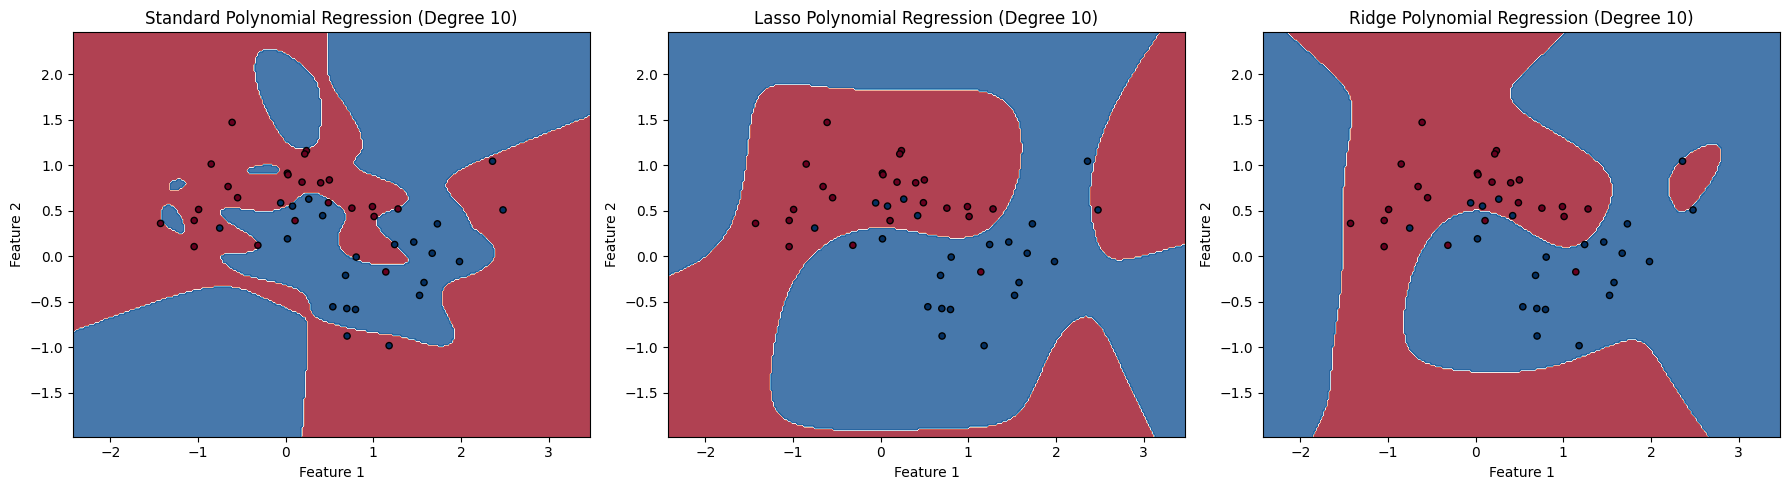

In [ ]:
# --- Function to Plot Decision Boundaries ---
# This function will help us visualize the separation created by each model.
def plot_decision_boundary(model, X, y, poly_features_transformer, title):
    # 1. Determine Plot Boundaries:
    # We find the min/max values of our features (Feature 1 and Feature 2) and add a margin (1 unit)
    # to ensure the decision boundary is fully visible across the plot area.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # 2. Create a Meshgrid:
    # `np.meshgrid` creates a grid of points covering the entire feature space.
    # `0.02` is the step size, determining the resolution of the grid.
    # We'll make predictions for every point in this grid to draw the boundary.
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # 3. Predict on the Meshgrid:
    # `np.c_[xx.ravel(), yy.ravel()]` combines the flattened x and y grid points into pairs (like our original X).
    # `poly_features_transformer.transform()`: We transform these grid points into polynomial features,
    #                                       just as we did for our training and test data.
    # `model.predict()`: The model then predicts an output (a continuous value) for each grid point.
    Z = model.predict(poly_features_transformer.transform(np.c_[xx.ravel(), yy.ravel()]))

    # 4. Classify Predictions:
    # Since our models are regression models, their output is continuous. For classification,
    # we apply a threshold. Here, we say any prediction > 0.5 belongs to class 1, otherwise class 0.
    # `astype(int)` converts the boolean (True/False) to integer (1/0).
    Z = (Z > 0.5).astype(int)
    # `reshape(xx.shape)`: Reshape the predictions back into the original grid shape for plotting.
    Z = Z.reshape(xx.shape)

    # 5. Plot the Decision Boundary:
    # `plt.contourf` fills contours based on the classification (`Z`) across the grid (`xx`, `yy`).
    # `alpha=0.8`: Makes the filled areas semi-transparent.
    # `cmap='RdBu'`: Uses the red-blue colormap to show the two class regions.
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='RdBu')

    # 6. Plot Original Data Points:
    # Overlay the actual data points on top of the decision boundary.
    # `c=y`: Color based on actual class labels.
    # `edgecolors='k'`: Black edges for visibility.
    # `s=20`: Set marker size.
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', s=20)

    # 7. Customize Plot:
    plt.title(title) # Set the title of the subplot (e.g., model name).
    plt.xlabel('Feature 1') # Label for the x-axis.
    plt.ylabel('Feature 2') # Label for the y-axis.
    plt.xlim(xx.min(), xx.max()) # Set x-axis limits to cover the entire grid.
    plt.ylim(yy.min(), yy.max()) # Set y-axis limits to cover the entire grid.

# --- Create and Display Subplots ---
# We'll create a figure to hold three side-by-side plots, one for each model.
plt.figure(figsize=(18, 5)) # Set the overall figure size for better readability of three plots.

# Subplot 1: Standard Polynomial Regression
plt.subplot(1, 3, 1) # 1 row, 3 columns, this is the 1st plot.
plot_decision_boundary(lin_reg, X_test, y_test, poly_features, 'Standard Polynomial Regression (Degree 10)')

# Subplot 2: Lasso Polynomial Regression
plt.subplot(1, 3, 2) # 1 row, 3 columns, this is the 2nd plot.
plot_decision_boundary(lasso_reg, X_test, y_test, poly_features, 'Lasso Polynomial Regression (Degree 10)')

# Subplot 3: Ridge Polynomial Regression
plt.subplot(1, 3, 3) # 1 row, 3 columns, this is the 3rd plot.
plot_decision_boundary(ridge_reg, X_test, y_test, poly_features, 'Ridge Polynomial Regression (Degree 10)')

plt.tight_layout() # Automatically adjusts subplot parameters for a tight layout, preventing labels/titles from overlapping.
plt.show() # Displays all the generated plots.

In [ ]:
# This cell is currently empty. It can be used for further analysis or experimentation if needed.
# Feel free to add any new code here to explore more or try different parameters!

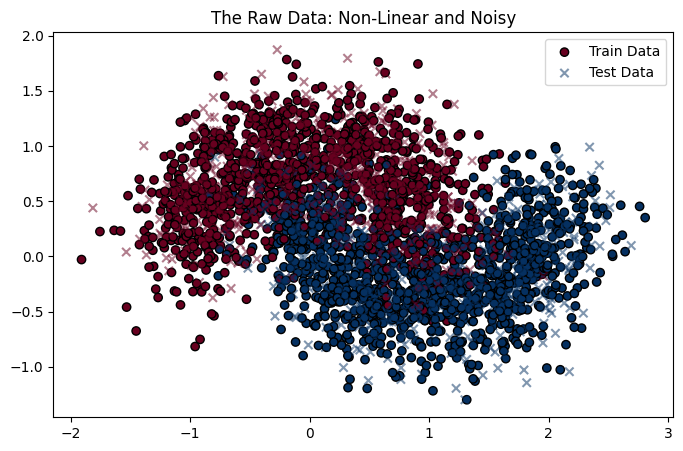

In [ ]:
# First, let's import the necessary libraries.
# NumPy is crucial for numerical operations, especially with arrays.
import numpy as np
# Matplotlib is our go-to library for creating visualizations like plots.
import matplotlib.pyplot as plt
# From scikit-learn, `make_moons` helps us generate a synthetic, non-linear dataset.
from sklearn.datasets import make_moons
# `train_test_split` is used to divide our data into training and testing sets,
# which is essential for evaluating model performance on unseen data.
from sklearn.model_selection import train_test_split

# --- Data Generation ---
# We're generating a dataset that resembles two intertwined half-moons.
# This is a classic synthetic dataset for testing classification algorithms
# on non-linearly separable data.
# `n_samples=150`: We'll create 150 data points in total.
# `noise=0.30`: We add a bit of random noise to make the problem more realistic and challenging.
# `random_state=42`: This ensures that our data generation is reproducible.
#                    If you run this code again, you'll get the exact same dataset.
X, y = make_moons(n_samples=3000, noise=0.30, random_state=42)

# --- Data Splitting ---
# Now, we split our generated data into training and testing sets.
# The model will learn from the training data and be evaluated on the test data.
# `test_size=0.3`: 30% of the data will be used for testing, and 70% for training.
# `random_state=42`: Again, for reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- Data Visualization ---
# It's always a good practice to visualize your raw data to understand its distribution
# and whether the classes are easily separable.
plt.figure(figsize=(8, 5)) # Creates a new figure and sets its size to 8x5 inches.

# Plotting the training data:
# `X_train[:, 0]` refers to the first feature (x-coordinate) of the training data.
# `X_train[:, 1]` refers to the second feature (y-coordinate) of the training data.
# `c=y_train`: The color of each point is determined by its class label (y_train).
# `cmap='RdBu'`: Uses a Red-Blue colormap to distinguish between classes.
# `edgecolors='k'`: Adds a black edge to each point for better visibility.
# `label='Train Data'`: A label for this set of points, to be used in the legend.
plt.scatter(
    X_train[:, 0], X_train[:, 1],
    c=y_train, cmap='RdBu', edgecolors='k', label='Train Data'
)

# Plotting the test data:
# Similar to training data, but we use a different marker and transparency
# to visually distinguish it from the training data.
# `marker='x'`: Uses 'x' symbols for test points.
# `alpha=0.5`: Makes the test points semi-transparent.
plt.scatter(
    X_test[:, 0], X_test[:, 1],
    c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data'
)

plt.title("The Raw Data: Non-Linear and Noisy") # Sets the title of our plot.
plt.legend() # Displays the legend, showing what 'Train Data' and 'Test Data' represent.
plt.show() # Renders the plot and displays it.